<a href="https://colab.research.google.com/github/AncaraniJuanDiego/IAModelosDeRegresi-n./blob/main/TP_IA_PCA_VideoGamesSales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
df= pd.read_excel('VideoGamesSales.xlsx')
df.head(10)



,Platform,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Rating,Critic_Score_Class
0,Wii,Sports,Nintendo,41.36,28.96,3.77,8.45,82.54,E,Bueno
1,Wii,Racing,Nintendo,15.68,12.80,3.79,3.29,35.57,E,Excelente
2,Wii,Sports,Nintendo,15.61,10.95,3.28,2.95,32.78,E,Excelente
3,DS,Platform,Nintendo,11.28,9.15,6.50,2.88,29.81,E,Excelente
4,Wii,Misc,Nintendo,13.96,9.18,2.93,2.84,28.92,E,Malo
5,Wii,Platform,Nintendo,14.48,6.95,4.70,2.25,28.38,E,Excelente
6,DS,Racing,Nintendo,9.71,7.48,4.13,1.90,23.22,E,Excelente
7,Wii,Sports,Nintendo,8.92,8.03,3.60,2.15,22.70,E,Excelente
8,X360,Misc,Microsoft Game Studios,15.02,4.91,0.24,1.69,21.86,E,Aceptable
9,Wii,Sports,Nintendo,9.01,8.49,2.53,1.77,21.79,E,Excelente


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7112 entries, 0 to 7111
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Platform            7112 non-null   object 
 1   Genre               7112 non-null   object 
 2   Publisher           7112 non-null   object 
 3   NA_Sales            7112 non-null   float64
 4   EU_Sales            7112 non-null   float64
 5   JP_Sales            7112 non-null   float64
 6   Other_Sales         7112 non-null   float64
 7   Global_Sales        7112 non-null   float64
 8   Rating              7112 non-null   object 
 9   Critic_Score_Class  7112 non-null   object 
dtypes: float64(5), object(5)
memory usage: 555.8+ KB


,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,7112.000000,7112.000000,7112.000000,7112.000000,7112.000000
mean,0.388567,0.232537,0.062652,0.081347,0.765307
std,0.953982,0.680028,0.283475,0.265864,1.936692
min,0.000000,0.000000,0.000000,0.000000,0.010000
25%,0.060000,0.020000,0.000000,0.010000,0.110000
50%,0.150000,0.060000,0.000000,0.020000,0.290000
75%,0.390000,0.202500,0.010000,0.070000,0.742500
max,41.360000,28.960000,6.500000,10.570000,82.540000


1. Visualizar matriz de correlación entre variables.

In [ ]:
features = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']

print('Correlation in sales features: ')
print(df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']].corr())


x= df[features].dropna()

Correlation in sales features: 
              NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales
NA_Sales      1.000000  0.838223  0.465930     0.727575      0.954936
EU_Sales      0.838223  1.000000  0.518536     0.718245      0.938461
JP_Sales      0.465930  0.518536  1.000000     0.393503      0.611947
Other_Sales   0.727575  0.718245  0.393503     1.000000      0.805426
Global_Sales  0.954936  0.938461  0.611947     0.805426      1.000000


**NA_Sales - EU_Sales - Other_Sales** → Altamente correlacionadas respecto a las ventas globales. Esto determina la alta influencia que tienen estas tres regiones en ventas generales.

**JP_Sales** → correlación más débil, cuando se trata de calcular 'Global_sales' la región japonesa es la que menos influencia tiene.


1.2 Estandarización → escalado de variables con media y varianza ~ (0 - 1)

* al modelo se le facilitará calcular los PCA

Formula → (x- u) / o

In [ ]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

**Aplicación de PCA** → Análisis de Componentes Principales.
* Algoritmo de ML NO SUPERVISADO.

* No predecir una variable respuesta, sino estudiar respuestas con ayuda de variables existentes.

Decidir cuántas dimensiones queremos bajar. En este caso, reducimos de 4 variables de ventas a 2 componentes principales para poder visualizar.



* PC1 : Captura el 'volumen total' de ventas.

Cálculo = $$PC1 \approx (NA\_Sales) + (EU\_Sales) + (JP\_Sales) + ( Other\_Sales)$$
* PC2 : Capturar las diferencias (por ejemplo, qué hace que un juego sea un éxito en Japón pero no en EE. UU.).

$$PC2 \approx (NA\_Sales) - (EU\_Sales) + ( JP\_Sales)$$

In [ ]:
pca = PCA (n_components=2)
principalComplements = pca.fit_transform(x_scaled)

#convertimos a dataframe para facilidad de manejo..
pca_df = pd.DataFrame(data = principalComplements,
                      columns = ['PC 1 Global Sales', 'PC 2 Differential regional'])

#añadimos información extra para identificar los juegos en los ploteos.

pca_df['Plataform'] = df['Platform']
pca_df['Genre'] = df['Genre']
pca_df['Publisher'] = df['Publisher']
pca_df['Critic_Score_Class'] = df['Critic_Score_Class']


#Mostrar juegos con mayor exito global (según PCA)

print('---VideoGames Global Sales (PC1): ---')
display(pca_df.sort_values('PC 1 Global Sales', ascending=False).head(5))


---VideoGames Global Sales (PC1): ---


,PC 1 Global Sales,PC 2 Differential regional,Plataform,Genre,Publisher,Critic_Score_Class
0,67.328423,-13.337013,Wii,Sports,Nintendo,Bueno
1,30.026225,2.076804,Wii,Racing,Nintendo,Excelente
3,27.582242,12.894000,DS,Platform,Nintendo,Excelente
2,27.146917,1.225935,Wii,Sports,Nintendo,Excelente
11,25.637888,-14.643984,PS2,Action,Take-Two Interactive,Excelente


¿Qué pasó acá?

1. Ventas globales:
¿Por qué las ventas del videojuego 'Wii Sports' pasaron de 82 mill a 67 mill?

* 1ro estandariza las variables, hace una diferencia entre el valor real y el promedio de ventas globales y divide entre el desvío estándar, con este cálculo los valores del df se centralizan.

* 2do Observa la correlación entre variables y extrae los loading (cargas). Cómo features cómo (NA_Sales EU_Sales Other_Sales) están altamente correlacionadas, a excepción de JP_Sales. El modelo asume que los loadings de las 3 variables será más alto que JP_Sales. Respectivamente:


         * (0,52)² = 0.2704
         * (0.51)² = 0.2601
         * (0.44)² = 0.1936
         * (0.52)² = 0.2704
  * La suma de loading debe ser 1: **0.2704 + 0.2601 + 0.1936 + 0.2704 ~ 1**


  * 2ro calculo final de la variable:

  W = (0.5 * Z) + (0.5 * Z) + (0.4 * Z) + (0.5 * Z)

  GlobalVent_WiiSpo =  (32.5 * 0.52) + (30.1 * 0.51) + (9.2 * 0.44) + (59.6 * 0.52)      =  **67,32**



2. Diferenciación regional:

* Como los loadings en PC1 eran positivos, el PC2 está obligado a usar signos opuestos para medir algo distinto.

* El algoritmo detecta que hay un grupo de datos (los juegos japoneses) que no encajan bien en la línea del "Éxito Occidental".

* Para capturar esa diferencia, el modelo asigna un loading positivo grande a Japón y loadings negativos a Occidente. Así, crea un eje que separa los perfiles de consumo.

PC2≈(-0.25 * NA_Sales) − (-0.25 * EU_Sales) + (0.25 * JP_Sales)

DiffReg_WiisPO = (-0.25 * 32.5)−(0.25 * 30.1)+(0.25 * 9.2)
               = -14,6 - 12,04 + 6.09 = **-13,33** (éxito mayormente occidental)

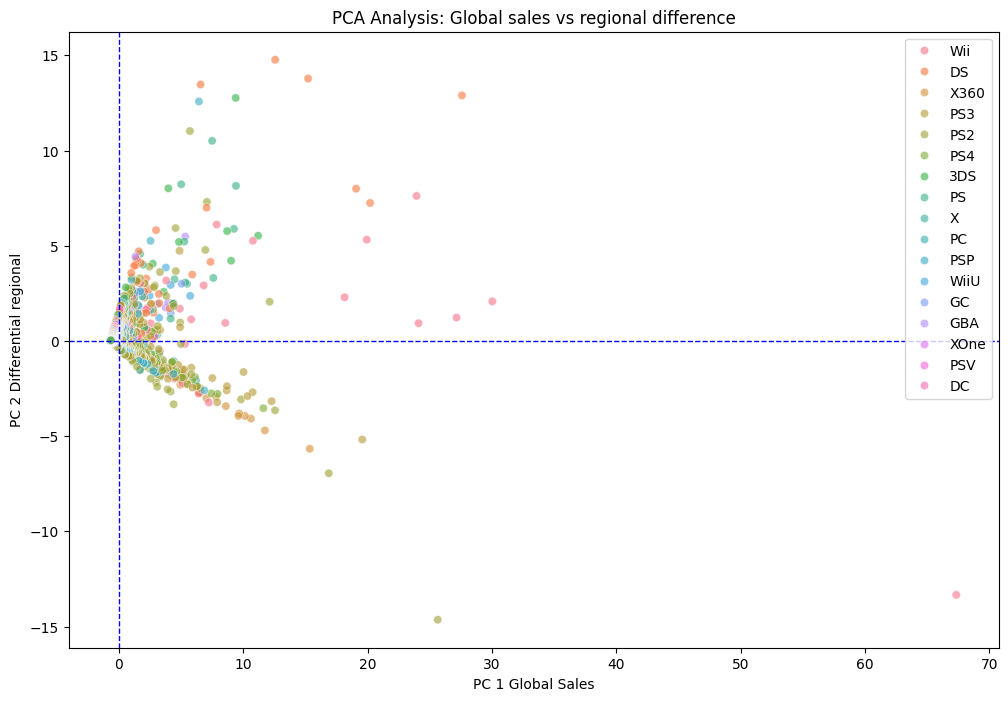

In [ ]:
plt.figure(figsize = (12,8))
scatter = sns.scatterplot (
    x = 'PC 1 Global Sales',
    y = 'PC 2 Differential regional',
    data = pca_df,
    alpha = 0.6,
    hue = 'Plataform'
)

# Lineas de preferencia (original blue lines at 0)
plt.axhline (0, color = 'blue', linestyle = '--', linewidth = 1)
plt.axvline (0, color = 'blue', linestyle = '--', linewidth = 1)

plt.title('PCA Analysis: Global sales vs regional difference')
plt.xlabel('PC 1 Global Sales')
plt.ylabel('PC 2 Differential regional')
plt.legend()
plt.show()

Línea Azul (vertical) : representa el 'éxito' promedio a nivel global, si un juego se extiende de ese límite, se lo considera un éxito global.

Línea Azul (horizontal): representa la diferenciación regional promedio.

**Eje x: Global Sales (cantidad de copias vendidas en total)**

* Las variables más a la derecha indican los juegos más vendidos, que han superado el promedio de ventas globales (luego de la línea azul vertical), a la izquierda de la línea, lo contrario (juegos que fueron un fracaso).

**Eje y: differential regional (diferenciación entre regiones)**

* mayor a 0 Diferenciación positiva.

* menor a 0 Diferenciación negativa.

→ Que un juego tenga diferenciación positiva y alta, indican aquellos juegos exitosos orientalmente (JAPÓN)

→ Aquellos juegos que se encuentran debajo de 0 (dif negativa), indican aquellos juegos exitosos occidentalmente (NA Y EUROPA).

→ Aquellos juegos que se encuentran en una región estacionaria (tienden a 0), indica que fue vendido balanceadamente en las regiones (en porciones similares).


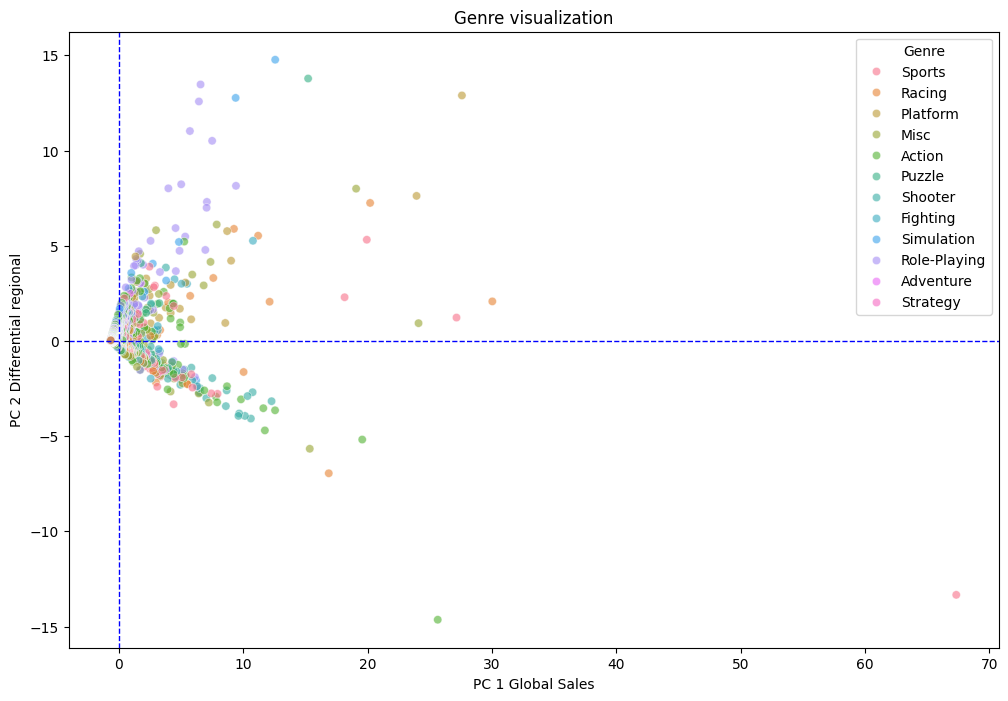

In [ ]:
#Adicional → genero
plt.figure(figsize = (12,8))
scatter = sns.scatterplot (
    x = 'PC 1 Global Sales',
    y = 'PC 2 Differential regional',
    data = pca_df,
    alpha = 0.6,
    hue = 'Genre'
)

#Lineas de preferencia

plt.axhline (0, color = 'blue', linestyle = '--', linewidth = 1)
plt.axvline (0, color = 'blue', linestyle = '--', linewidth = 1)

plt.title('Genre visualization')
plt.xlabel('PC 1 Global Sales')
plt.ylabel('PC 2 Differential regional')
plt.show()

Exito global y diferenciación regional (contexto de 'estilo de juego')



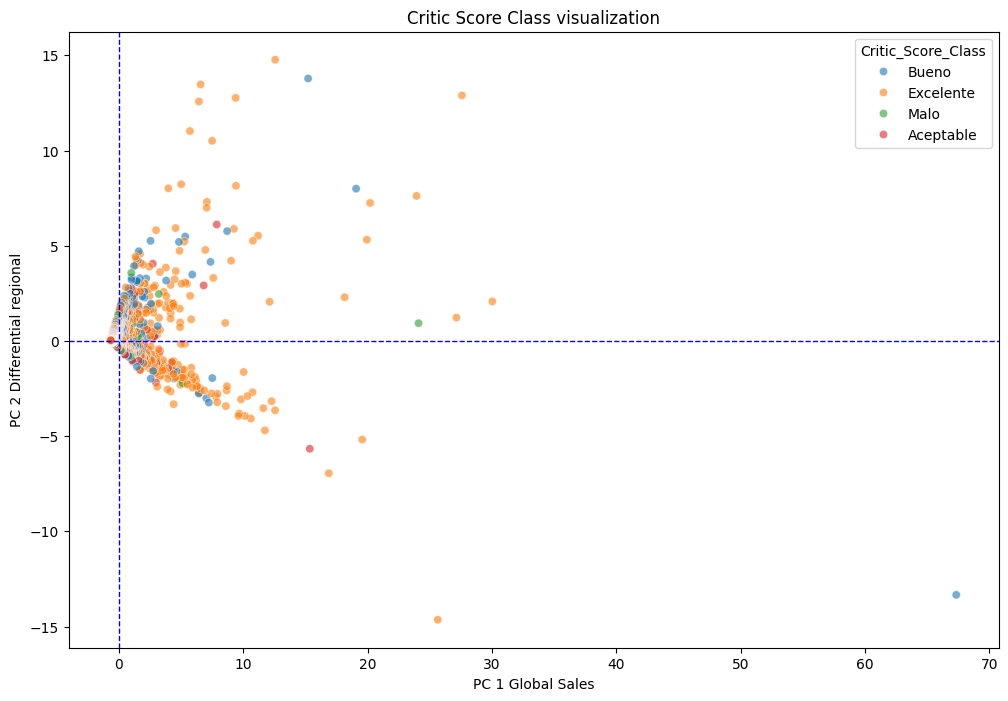

In [ ]:
#adicional → crítica
plt.figure(figsize = (12,8))
scatter = sns.scatterplot (
    x = 'PC 1 Global Sales',
    y = 'PC 2 Differential regional',
    data = pca_df,
    alpha = 0.6,
    hue = 'Critic_Score_Class'
)

#Lineas de preferencia

plt.axhline (0, color = 'blue', linestyle = '--', linewidth = 1)
plt.axvline (0, color = 'blue', linestyle = '--', linewidth = 1)

plt.title('Critic Score Class visualization')
plt.xlabel('PC 1 Global Sales')
plt.ylabel('PC 2 Differential regional')
plt.show()

Interpretación de la varianza→ verificar cuanta información sobrevivio a la simplificación.

In [ ]:
#varianza aplicada

variance = pca.explained_variance_ratio_
print(f'varianza explicada por PC1: {variance[0]:.2%} ')
print(f'varianza explicada por PC2: {variance[1]:.2%} ')
print(f'total de informacion obtenida: {sum(variance):.2%}')

varianza explicada por PC1: 71.63% 
varianza explicada por PC2: 16.76% 
total de informacion obtenida: 88.39%


**Control de calidad** → que tanta información de 4 regiones (NA, EUR, JP, OTHER sales) pudo abordar el modelo para predecir y estandarizar en 2 columnas (PCA).

* PC1 (71,6%): Sólidamente, el 'éxito' de un videojuego puede ser explicado la mayoría de veces, gracias al PC1 -ventas globales-

* PC2 (16,7%) Débilmente, también puede ser explicado por la diferenciación regional, pero notoriamente es la parte que PC1 no pudo explicar.

* PC1 + PC2 (88.3%) estos dos componentes sólo pueden explicar el 88% del 'éxito' global comercial. **Hay otro 12% que aún no se evalúa**.

**Posibles razón:**

* Juegos famosos sin influencia comercial en ninguna de las 2 regiones, quizás en australia o latino américa.


**PC3 → Diferenciación en 'Other_regions'**

Nota: Visualizar que juegos han tenido un éxito descomunal no solo en 'NA-EU-JP' sino también,  en el resto del mundo.

Cálculo = (-0.15 * Zna) + (-0.15 * Zeu) + (-0.15 * Zjap) + (0.95 * Zothers)

* Pesos de loadings balanceados, dando más peso al de 'Others_Sales'.

In [ ]:
# 3. Configuramos el PCA para 3 componentes (Captura el ~96% de la varianza)
features = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
x = df[features].dropna()
y = df['Genre']

x_scaled = StandardScaler().fit_transform(x)
pca = PCA(n_components=3)
principalComponents = pca.fit_transform(x_scaled)

pca_df = pd.DataFrame(data = principalComponents,
                      columns = ['PC 1 Global Sales',
                                 'PC 2 Differential regional',
                                 'PC3_Differential_Others'])

# Mostrar características
pca_df['Plataform'] = df['Platform']
pca_df['Genre'] = df['Genre']
pca_df['Publisher'] = df['Publisher']
pca_df['Critic_Score_Class'] = df['Critic_Score_Class']

# 6. Mostramos los juegos que más influyeron en el PC3 (Mercados Emergentes)
print("-- TOP 8 Videojuegos con mayor influencia en 'Other Regions' (PC3) que demaás regiones--")
display(pca_df.sort_values(by='PC3_Differential_Others', ascending=False).head(8))

-- TOP 8 Videojuegos con mayor influencia en 'Other Regions' (PC3) que demaás regiones--


,PC 1 Global Sales,PC 2 Differential regional,PC3_Differential_Others,Plataform,Genre,Publisher,Critic_Score_Class
11,25.637888,-14.643984,27.279498,PS2,Action,Take-Two Interactive,Excelente
30,16.876723,-6.951639,21.672953,PS2,Racing,Sony Computer Entertainment,Excelente
239,5.826468,-1.751289,9.065817,PS2,Sports,Konami Digital Entertainment,Excelente
304,4.403707,-3.325763,7.056807,PS2,Sports,Electronic Arts,Excelente
104,6.951442,4.779179,5.596443,PS2,Role-Playing,Square Enix,Excelente
188,4.992179,-0.162404,5.567299,PS2,Action,Konami Digital Entertainment,Excelente
482,3.089729,-2.403691,5.247861,PS2,Sports,Electronic Arts,Excelente
448,2.985198,-2.183954,4.753205,PS2,Racing,Electronic Arts,Aceptable


* Si el juego adquiere un puntaje alto en 'PC3_Differential_Others' significa que el juego fue un exito anomalo en las regiones de otros, no solo con un exito explicado en occidente-oriente.

In [ ]:
#Varianza explicada por PC3

pca = PCA(n_components=3)
pca.fit(x_scaled)

variance = pca.explained_variance_ratio_
print(f'varianza explicada por PC3: {variance[2]:.2%} ')

#varianza explicada acumulada
print(f"\nVarianza total explicada con 3 componentes: {sum(pca.explained_variance_ratio_):.2%}")

varianza explicada por PC3: 7.63% 

Varianza total explicada con 3 componentes: 96.02%


PC4 → Ajuste regional NA vs EUR.

* Aunque NA y EUR están altamente correlacionados (0.83), aun hay 17% restante de falta influencial, por ello vamos a observar 'para donde tira' el exito mayor del juego, para NA o Europa.

Calculo = (0.7 * Zna) + (-0.65 * Zeu)

In [ ]:
features = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
x = df[features].dropna()
y = df['Genre']

x_scaled = StandardScaler().fit_transform(x)
pca = PCA(n_components=4)
principalComponents = pca.fit_transform(x_scaled)

pca_df = pd.DataFrame(data = principalComponents,
                      columns = ['PC 1 Global Sales',
                                 'PC 2 Differential regional',
                                 'PC3_Differential_Others',
                                 'PC4_Differential_NA_EUR'])

pca_df['Plataform'] = df['Platform']
pca_df['Genre'] = df['Genre']
pca_df['Publisher'] = df['Publisher']
pca_df['Critic_Score_Class'] = df['Critic_Score_Class']

print('--Top 8 Juegos dominantes en NA VS EUROPA--')
display(pca_df.sort_values(by='PC4_Differential_NA_EUR', ascending=False).head(8))

--Top 8 Juegos dominantes en NA VS EUROPA--


,PC 1 Global Sales,PC 2 Differential regional,PC3_Differential_Others,PC4_Differential_NA_EUR,Plataform,Genre,Publisher,Critic_Score_Class
49,7.934716,-2.778589,-0.512352,6.578981,PS4,Sports,Electronic Arts,Excelente
95,4.401751,-1.057351,-3.830671,6.527416,PC,Role-Playing,Activision,Excelente
58,6.210757,-2.078395,-2.566901,6.129503,PC,Simulation,Electronic Arts,Excelente
52,7.430271,-2.754778,-0.396387,5.761917,PS4,Sports,Electronic Arts,Excelente
12,19.075189,7.996269,0.509672,5.467590,DS,Misc,Nintendo,Bueno
56,7.902206,-3.223803,2.408683,4.664942,PS3,Action,Electronic Arts,Excelente
10,19.567188,-5.180911,3.626502,4.636346,PS3,Action,Take-Two Interactive,Excelente
22,11.614721,-3.534049,0.439387,4.243266,PS4,Action,Take-Two Interactive,Excelente


* Mientras + alto el valor, el juego fue un éxito 'norte americano' y no terminó de encajar exitosamente en Europa. Viceversa si el valor es negativo.

In [ ]:
#Varianza explicada por PC4

pca = PCA(n_components=4)
pca.fit(x_scaled)

variance = pca.explained_variance_ratio_
print(f'varianza explicada por PC4: {variance[3]:.2%} ')

#varianza explicada acumulada
print(f"\nVarianza total explicada con 4 componentes: {sum(pca.explained_variance_ratio_):.2%}")

varianza explicada por PC4: 3.98% 

Varianza total explicada con 4 componentes: 100.00%


Resumen:

PC1 → Volumen total.

PC2 → Occidente vs Japón.

PC3 → Influencias en el resto del mundo.

PC4 → NA VS EUR (Ajuste fino).

* Juantas pueden explicar el 100% de la información no supervísada.

**Reporte de clasificación**

* Vamos a evaluar los 'aciertos' que el modelo puede hacer, al predecir el genero de un juego..

**Metricas:**

**1. Accuracy (exactitud) = (Verdaderos Pos + Verdadero Neg) / total**

* Porcentaje total de aciertos. ¿Que tan seguro es el modelo para predecir en general?


**2. Precision = Verdaderos Pos / Verdaderos Pos + Falsos Pos**

* De todos los juegos que eran un 'exito' para el modelo ¿cual es el porcentaje de aciertos?


**3. Recall (Exhaustividad) = Verdaderos Pos / Verdaderos Pos + Falsos Neg**

* De todos los juegos que eran un 'exito' para el modelo ¿Cuantos logra detectar?

**4. F1_score = metrica de ajuste, la mas importante. Es el promedio entre Precision y Recall.**

**5. Support = cantidad de juegos con ese genero.**

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


Accuracy (que tan seguido acierta el modelo): 0.2389
Precision: 0.1710
Recall: 0.2389
F1: 0.1185
              precision    recall  f1-score   support

      Action       0.24      0.94      0.38       334
   Adventure       0.00      0.00      0.00        47
    Fighting       0.00      0.00      0.00        86
        Misc       0.00      0.00      0.00        73
    Platform       0.50      0.01      0.03        72
      Puzzle       0.00      0.00      0.00        27
      Racing       0.00      0.00      0.00       114
Role-Playing       0.37      0.11      0.17       152
     Shooter       0.15      0.02      0.04       182
  Simulation       0.00      0.00      0.00        66
      Sports       0.21      0.02      0.03       215
    Strategy       0.00      0.00      0.00        55

    accuracy                           0.24      1423
   macro avg       0.12      0.09      0.05      1423
weighted avg       0.17      0.24      0.12      1423



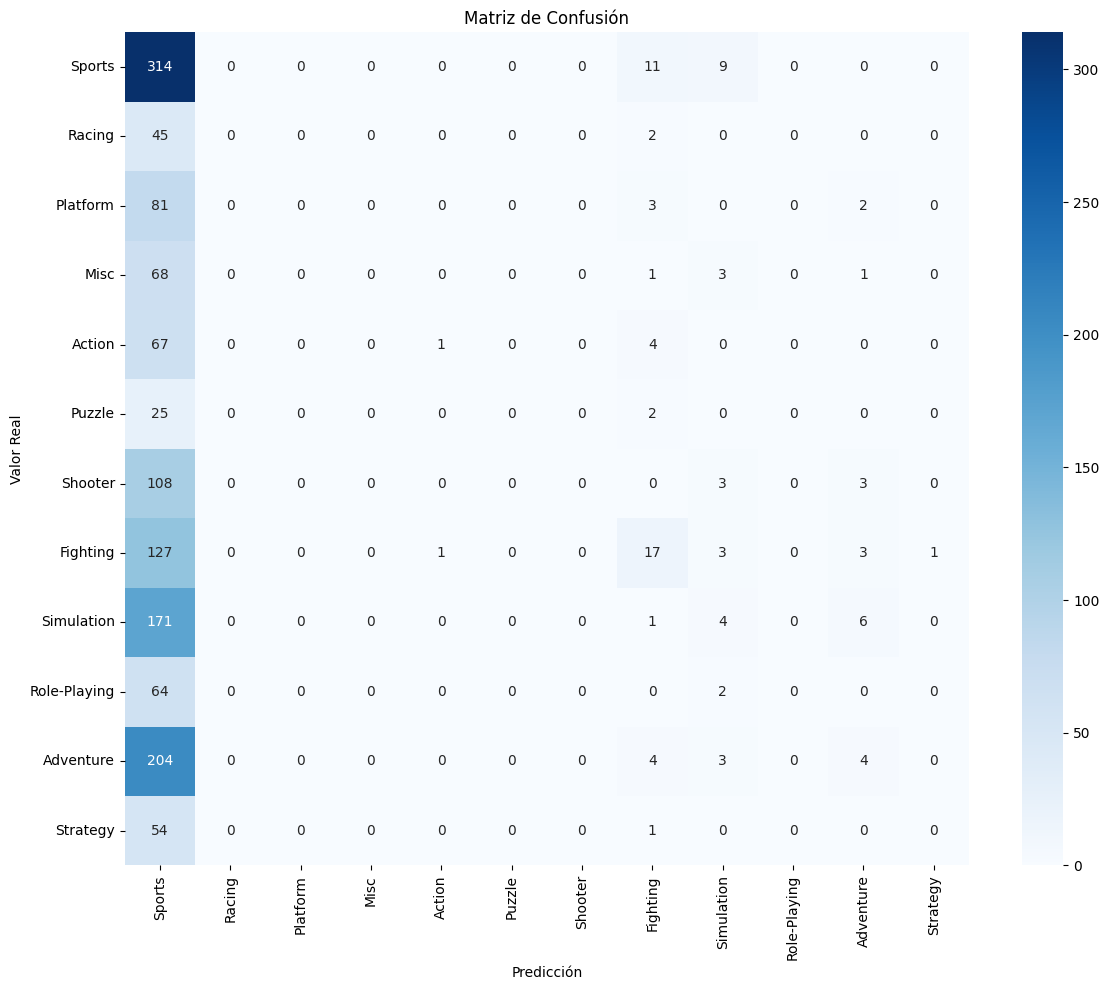

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Hacer predicciones.
y_pred = model.predict(X_test)
y_pred_base = y_pred

#Calcular metricas.

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

  print(f'Accuracy (que tan seguido acierta el modelo): {acc:.4f}')
  print(f'Precision: {prec:.4f}')
  print(f'Recall: {rec:.4f}')
  print(f'F1: {f1:.4f}')

#Reporte completo

print(classification_report(y_test, y_pred_base, zero_division=0))

#ploteo

cm = confusion_matrix(y_test, y_pred_base)
plt.figure(figsize=(10, 8)) # Increased figure size for better readability
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=y.unique(), yticklabels=y.unique())
plt.title('Confusion Matrix (recall frecuency)')
plt.xlabel('Prediction')
plt.ylabel('Real Value')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

  Vamos a estudiar la columna df['genre'] y entender cuales son las clases mayoritarias.

  * género 'action' con recall 0.94 → el modelo clasifica todos los juegos como de accion, y al disparar acierta con el 94%, pero su precisión es solo del 23,4%. Es decir que, cada 100 juegos solo acierta con 23-24 (que si eran de acción).
  * Otros géneros como 'Adventure', 'Fighting', 'Misc', 'Puzzle', 'Racing', 'Simulation' y 'Strategy' tienen recall 0. Por lo que el modelo los ignora completamente, no predijo ningún juego con estos géneros. En cambio se guió por los de 'action' por tener mayor support (334)

  Accuracy = 334/ 54 + 204 + 64 + 171 + 127 + 108 + 25 + 67 + 68 + 81 + 45 + 314   →    34/1423 = 0.234

  

**Interpretemos una columna: 'Shooter'**

presision: 15% → las veces que el modelo arriesgo y dijo que el juego es 'shooter' se equivocó la gran mayoría de veces, solo acertando con el 15%.

Recall: de todos los juegos que si eran 'shooter' solo acierta con el 2%, aproximadamente 4/182 juegos shooter que había.

f1_score = 4% de efectividad → realmente es modelo es flojo para predecir juegos de género 'shooter'.

* 114/182 juegos fueron falsos positivos de otros géneros. (60% de juegos shooter mal predichos).




**Gráfico .**

→ Problema con la columna 'sport' → el modelo entiende que 'ante la duda' todo juego es 'sport'. Por ejemplo, confunde 54 juegos que eran tipo 'strategy' como 'sport' y 84 juegos 'plataform', pero después de todo, acierta con 314/334 (94% efect).

El modelo es incapaz de predecir géneros como: 'strategy' - 'role_playing' - 'shooter', 'puzzle', 'misc', 'plataform' y 'racing'.
